In [1]:
"""Resolve project root dynamically for portable imports and data paths."""
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utility.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "utility.py").exists():
    raise RuntimeError("Could not locate project root containing utility.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
pd.set_option('mode.chained_assignment', None)
import utility
try:
    from pdf2image import convert_from_path
except ModuleNotFoundError:
    convert_from_path = None

from PIL import Image
from IPython.display import display


In [3]:
def _read_yeast_metadata():
    """Load precomputed yeast evolved-genome metadata CSV; fail fast if missing."""
    candidate_paths = [
        Path("yeast_evolved_genome_metadata.csv"),
        PROJECT_ROOT / "figure" / "main" / "fig6" / "yeast_evolved_genome_metadata.csv",
        PROJECT_ROOT / "figure" / "Supplementary" / "fig6" / "yeast_evolved_genome_metadata.csv",
        DATA_DIR / "yeast_evolved_genome_metadata.csv",
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            return pd.read_csv(candidate)

    searched = "\n".join(f"- {p}" for p in candidate_paths)
    raise FileNotFoundError(
        "Missing required input: yeast_evolved_genome_metadata.csv\n"
        "Searched:\n"
        f"{searched}\n\n"
        "Generate this file by running figure/main/fig6/evolved_genome_yeast_fasta.ipynb "
        "(the cell that writes df_full.to_csv('yeast_evolved_genome_metadata.csv', index=False))."
    )

df = _read_yeast_metadata()


In [4]:
# rearrange cols in df 
df = df[['Position', 'CHROM', 'REF', 'ALT', 'population_name', 'G70_ref_counts', 'accumulate_gain','G1410_ref_counts', 'G2640_ref_counts', 'G5150_ref_counts',
       'G7530_ref_counts', 'G10150_ref_counts', 'G70_alt_counts',
       'G1410_alt_counts', 'G2640_alt_counts', 'G5150_alt_counts',
       'G7530_alt_counts', 'G10150_alt_counts', 'kGain_evolved_genome']]

In [5]:
# data_all_copy.columns[-7:-1]

In [6]:
data_all_copy = df.copy()
all_mutation = pd.DataFrame() # The all_mutation dataframe contain generation and population wise accumulated gain

for i in data_all_copy.columns[-7:-1]:
    new_df_tmp = pd.DataFrame()
    new_df = data_all_copy[data_all_copy.loc[:, i]!=0]
    new_df_tmp = new_df[["population_name", 'CHROM', 'Position', 'REF','ALT']]
    new_df_tmp.loc[:, "generation"] = i
    new_df_tmp.loc[:, "AG"] = new_df.loc[:, "accumulate_gain"]
    new_df_tmp.loc[:, 'kGain_evolved_genome'] = new_df.loc[:, 'kGain_evolved_genome']
    new_df_tmp.loc[:, "allele count"] = new_df.loc[:, i]
    all_mutation = pd.concat([all_mutation, new_df_tmp], axis = 0)
    
    
all_mutation.reset_index(inplace=True, drop=True)
# all_mutation['generation_number'] = all_mutation['generation'].str.extract(r'(\d+)').astype(int)

all_mutation.head()

,population_name,CHROM,Position,REF,ALT,generation,AG,kGain_evolved_genome,allele count
0,P1C11,chrX,66,C,T,G70_alt_counts,6.067923,6.067923,7
1,P1C11,chrX,69,T,A,G70_alt_counts,-4.705100,-4.705100,7
2,P1C11,chrX,73,C,T,G70_alt_counts,3.963808,3.963808,7
3,P2B04,chrX,73,C,T,G70_alt_counts,3.963808,3.963808,5
4,P1B02,chrX,74,T,C,G70_alt_counts,-2.479826,-2.479826,5


In [7]:
# all_mutation

In [8]:
ann = pd.read_csv(
    str(DATA_DIR / "yeast_gene_annotations.tsv"),
    sep="	",
    on_bad_lines="skip",
)
ann.head()


,Gene_ORF,Gene,ORF,SGDID,Essential_by_yeastmine,Essential_by_Liu2015,Essential_by_Giaever2002,featureType,briefDescription,description,functionSummary,phenotypeSummary,chromosome,start,end,orf_strand,go_ids,go_terms,go_types
0,GAS5,GAS5,YOL030W,S000005390,False,False,False,ORF,"1,3-beta-glucanosyltransferase","1,3-beta-glucanosyltransferase; has similarity...",NaN,NaN,chrXV,268187,269641,1,GO:0005576;GO:0005618;GO:0005783;GO:0006074;GO...,extracellular region;cell wall;endoplasmic ret...,cellular_component;cellular_component;cellular...
1,GAS4,GAS4,YOL132W,S000005492,False,False,False,ORF,"1,3-beta-glucanosyltransferase","1,3-beta-glucanosyltransferase; involved with ...",NaN,NaN,chrXV,71300,72715,1,GO:0000324;GO:0005618;GO:0005886;GO:0009277;GO...,fungal-type vacuole;cell wall;plasma membrane;...,cellular_component;cellular_component;cellular...
2,GAS2,GAS2,YLR343W,S000004335,False,False,False,ORF,"1,3-beta-glucanosyltransferase","1,3-beta-glucanosyltransferase; involved with ...",NaN,NaN,chrXII,816094,817761,1,GO:0000324;GO:0005618;GO:0005737;GO:0005886;GO...,fungal-type vacuole;cell wall;cytoplasm;plasma...,cellular_component;cellular_component;cellular...
3,SLC1,SLC1,YDL052C,S000002210,False,False,False,ORF,1-acyl-sn-glycerol-3-phosphate acyltransferase,1-acyl-sn-glycerol-3-phosphate acyltransferase...,NaN,NaN,chrIV,362672,363583,-1,GO:0003841;GO:0005783;GO:0005811;GO:0006629;GO...,1-acylglycerol-3-phosphate O-acyltransferase a...,molecular_function;cellular_component;cellular...
4,FAB1,FAB1,YFR019W,S000001915,False,False,False,ORF,1-phosphatidylinositol-3-phosphate 5-kinase,1-phosphatidylinositol-3-phosphate 5-kinase; v...,NaN,Non-essential gene; null mutant has defective ...,chrVI,184502,191338,1,GO:0000166;GO:0000285;GO:0000329;GO:0005524;GO...,nucleotide binding;1-phosphatidylinositol-3-ph...,molecular_function;molecular_function;cellular...


In [9]:
# replace in df Chrom in that chrmt with chrmito
ann['chromosome'] = ann['chromosome'].replace('chrmt', 'chrmito')

In [10]:
import pandas as pd

# Ensure `CHROM` and `chromosome` are in the same format
ann['chromosome'] = ann['chromosome'].str.lower()
all_mutation['CHROM'] = all_mutation['CHROM'].str.lower()


In [11]:
for i in range(all_mutation.shape[0]):

    chrom = all_mutation.loc[i, "CHROM"]

    pos = all_mutation.loc[i, "Position"]

    tmp = ann[(ann["chromosome"] == chrom) & (ann["start"] <= pos) & (pos <= ann["end"])]

    if tmp.shape[0] != 0:
        all_mutation.loc[i, "essential"] = tmp["Essential_by_Liu2015"].values[0]

# Keep compatibility with downstream filtering code.
all_mutation["essential_is_ambiguous"] = False
all_mutation["has_gene_annotation"] = all_mutation["essential"].notna()


In [12]:
all_mutation["essential"].dropna().value_counts()


essential
False    209470
True       9661
Name: count, dtype: int64

In [13]:
all_mutation

,population_name,CHROM,Position,REF,ALT,generation,AG,kGain_evolved_genome,allele count,essential,essential_is_ambiguous,has_gene_annotation
0,P1C11,chrx,66,C,T,G70_alt_counts,6.067923,6.067923,7,NaN,False,False
1,P1C11,chrx,69,T,A,G70_alt_counts,-4.705100,-4.705100,7,NaN,False,False
2,P1C11,chrx,73,C,T,G70_alt_counts,3.963808,3.963808,7,NaN,False,False
3,P2B04,chrx,73,C,T,G70_alt_counts,3.963808,3.963808,5,NaN,False,False
4,P1B02,chrx,74,T,C,G70_alt_counts,-2.479826,-2.479826,5,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
500919,P3D10,chriv,1525964,C,T,G10150_alt_counts,8.835324,8.835324,4,NaN,False,False
500920,P3D11,chriv,1525964,C,T,G10150_alt_counts,8.835324,8.835324,2,NaN,False,False
500921,P3E08,chriv,1525964,C,T,G10150_alt_counts,8.835324,8.835324,2,NaN,False,False
500922,P3F09,chriv,1525964,C,T,G10150_alt_counts,8.835324,8.835324,6,NaN,False,False


##### Box plot of wild type evolved kGain vs generation

In [14]:
all_mutation['generation_number'] = all_mutation['generation'].str.extract(r'G(\d+)_')[0].astype(int)


Label=G70_alt_counts, p_raw=3.72e-16, p_reported=3.72e-16, effect size=3.06e-01, 95% CI [2.77e-01, 3.51e-01]
Label=G1410_alt_counts, p_raw=1.69e-32, p_reported=1.02e-31, effect size=3.14e-01, 95% CI [2.42e-01, 4.39e-01]
Label=G2640_alt_counts, p_raw=1.39e-24, p_reported=2.08e-24, effect size=3.65e-01, 95% CI [2.77e-01, 4.93e-01]
Label=G5150_alt_counts, p_raw=1.52e-28, p_reported=4.57e-28, effect size=2.97e-01, 95% CI [2.25e-01, 3.76e-01]
Label=G7530_alt_counts, p_raw=6.82e-23, p_reported=8.18e-23, effect size=2.89e-01, 95% CI [2.05e-01, 3.88e-01]
Label=G10150_alt_counts, p_raw=1.04e-27, p_reported=2.08e-27, effect size=2.97e-01, 95% CI [2.04e-01, 3.59e-01]


,category,x_column,y_column,hue_column,group1_name,group2_name,n_group1,n_group2,test,alternative,effect_size_name,effect_size,ci_level,ci_low,ci_high,p_raw,p_adjust_method,p_adjusted
0,G70_alt_counts,generation,kGain_evolved_genome,essential,True,False,520,30570,Mann-Whitney U,greater,median_based_distance,0.306238,95,0.277213,0.351009,3.721172e-16,fdr_bh,3.721172e-16
1,G1410_alt_counts,generation,kGain_evolved_genome,essential,True,False,1054,31038,Mann-Whitney U,greater,median_based_distance,0.314396,95,0.241803,0.438590,1.693824e-32,fdr_bh,1.016294e-31
2,G2640_alt_counts,generation,kGain_evolved_genome,essential,True,False,1310,35423,Mann-Whitney U,greater,median_based_distance,0.365292,95,0.277480,0.492794,1.387013e-24,fdr_bh,2.080519e-24
3,G5150_alt_counts,generation,kGain_evolved_genome,essential,True,False,1925,35544,Mann-Whitney U,greater,median_based_distance,0.297057,95,0.225120,0.376089,1.523189e-28,fdr_bh,4.569566e-28
4,G7530_alt_counts,generation,kGain_evolved_genome,essential,True,False,2271,39244,Mann-Whitney U,greater,median_based_distance,0.288513,95,0.205078,0.387996,6.815807e-23,fdr_bh,8.178969e-23
5,G10150_alt_counts,generation,kGain_evolved_genome,essential,True,False,2581,37651,Mann-Whitney U,greater,median_based_distance,0.297489,95,0.204409,0.358608,1.040298e-27,fdr_bh,2.080596e-27


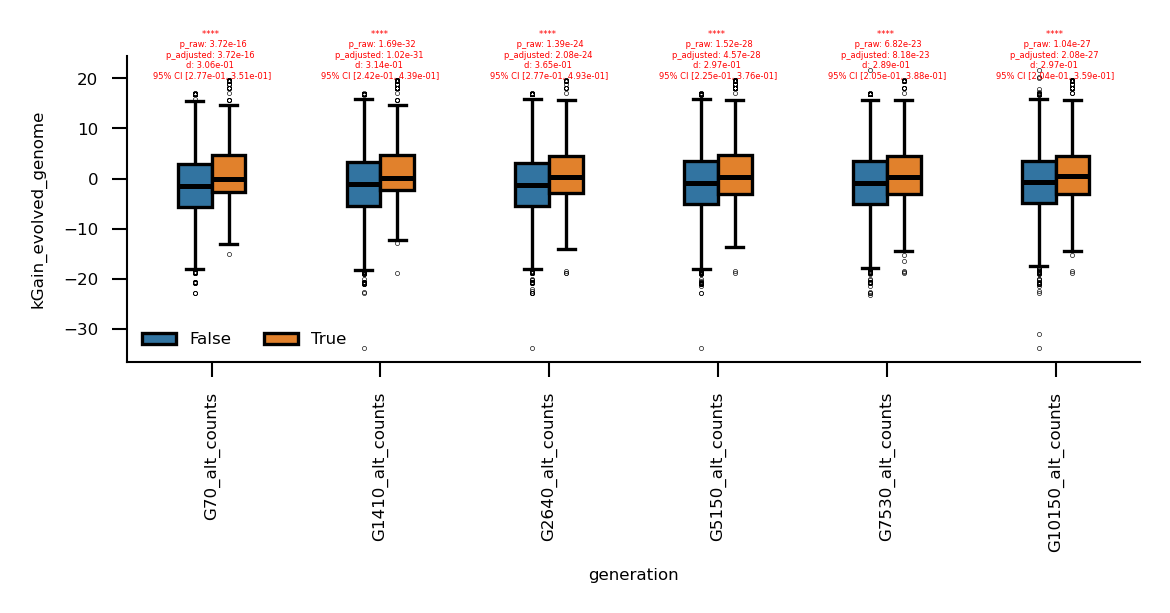

In [15]:
# Plot each score's cumulative sum separately
import seaborn as sns

plot_data = all_mutation.dropna(subset=['essential', 'kGain_evolved_genome']).copy()
plot_data = plot_data.loc[~plot_data['essential_is_ambiguous'].fillna(False)].copy()
plot_data['essential'] = plot_data['essential'].astype(bool)
plot_data['generation_number'] = plot_data['generation'].str.extract(r'G(\d+)_')[0].astype(int)
generation_order = (
    plot_data[['generation', 'generation_number']]
    .drop_duplicates()
    .sort_values('generation_number')['generation']
    .tolist()
)

fig, ax = plt.subplots(1, 1, figsize=(4, 2.1), dpi=300)
ax = sns.boxplot(
    x='generation',
    y='kGain_evolved_genome',
    data=plot_data,
    hue='essential',
    order=generation_order,
    ax=ax,
    boxprops=dict(edgecolor='black', linewidth=0.8),
    whiskerprops=dict(color='black', linewidth=0.8),
    capprops=dict(color='black', linewidth=0.8),
    flierprops=dict(marker='o', markeredgecolor='black'),
    width=0.4,
    linewidth=0.8,
    fliersize=0.15,
    dodge=True,
    medianprops={'color': 'black', 'linewidth': 1.2}
)
ax = utility.custom_figure_axis(ax=ax, fontsize=4, show_ticks=True, rotation=90)
ax = utility.return_box_with_p_effect_size(
    ax,
    data=plot_data,
    x_columns='generation',
    y_columns='kGain_evolved_genome',
    group1_name=True,
    group2_name=False,
    y_pos=20,
    hue_columns='essential',
    fontsize=2,
    p_adjust_method='fdr_bh',
    alternative='greater'
)

ax.legend(ncol=2, frameon=False, fontsize=4)
plt.tight_layout()
plt.savefig('yeast_essential_generation_boxplot_python.pdf', dpi=300)

fig7b_stats = utility.summarize_boxplot_pairwise_stats(
    data=plot_data,
    x_columns='generation',
    y_columns='kGain_evolved_genome',
    group1_name=True,
    group2_name=False,
    hue_columns='essential',
    p_adjust_method='fdr_bh',
    alternative='greater',
)
fig7b_stats.to_csv('fig7b_stats_summary.csv', index=False)
fig7b_stats
